# Creative Suffix Attribution Visualizations

Alternative ways to visualize how prefix features influence suffix predictions:

1. **Sankey Diagram** - Flow from features to predictions
2. **Radial Heatmap** - Circular polar visualization
3. **Stream/Area Chart** - Feature importance evolution across suffix
4. **Chord Diagram** - Feature-to-prediction connections
5. **Bump Chart** - Feature rank changes across suffix steps

In [1]:
import sys
from pathlib import Path
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, ConnectionPatch
from matplotlib.collections import LineCollection
import matplotlib.cm as cm

from src.interpretability.config.helpdesk_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

%matplotlib inline

In [2]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Cases: {len(eval_helper.cases)}")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

In [3]:
# Configuration
CASE_NAME = "Case 1114"
PREFIX_LENGTH = 3
TARGET = CONFIG.concept_name

# Get prefix
case = eval_helper.cases[CASE_NAME]
for pl, prefix, suffix in eval_helper._iterate_case(case):
    if pl == PREFIX_LENGTH:
        break

process = ([t.squeeze(0) for t in prefix[0]], [t.squeeze(0) for t in prefix[1]])
print(f"Case: {CASE_NAME}, Prefix length: {PREFIX_LENGTH}")

Case: Case 1114, Prefix length: 3


In [ ]:
# Compute attributions for all suffix steps
def compute_all_suffix_attributions(tool, process, prefix_len, target, n_steps=50):
    results = []
    feature_names = None
    step_labels = None
    
    for suffix_step in range(tool.model.seq_len_pred):
        try:
            attr_map = tool.compute_attribution_map(
                process=process, prefix_length=prefix_len, target=target,
                target_class='auto', suffix_scope='step', suffix_step=suffix_step,
                method='integrated_gradients', n_steps=n_steps
            )
            if feature_names is None:
                feature_names = attr_map.feature_names
                step_labels = attr_map.step_labels
            
            # Extract predicted activity name
            pred_name = attr_map.target_description.split('=')[1].split('(')[0].strip() if '=' in attr_map.target_description else f"Step {suffix_step}"
            results.append((suffix_step, attr_map, pred_name))
            print(f"  Suffix {suffix_step}: {pred_name}")
            
            if 'EOS' in attr_map.target_description:
                break
        except Exception as e:
            print(f"  Suffix {suffix_step}: Error - {e}")
            break
    
    return results, feature_names, step_labels

print("Computing attributions...")
results, feature_names, step_labels = compute_all_suffix_attributions(
    tool, process, PREFIX_LENGTH, TARGET, n_steps=CONFIG.ig_steps
)
print(f"\nFeatures: {len(feature_names)}, Prefix steps: {len(step_labels)}, Suffix steps: {len(results)}")

In [5]:
# Build attribution cube: (features, prefix_steps, suffix_steps)
def build_attribution_cube(results, feature_names):
    n_features = len(feature_names)
    n_prefix = len(results[0][1].step_labels)
    n_suffix = len(results)
    
    cube = np.zeros((n_features, n_prefix, n_suffix))
    suffix_labels = []
    
    for s_idx, (_, attr_map, pred_name) in enumerate(results):
        suffix_labels.append(pred_name)
        for f_idx, feat_name in enumerate(feature_names):
            if feat_name in attr_map.attributions:
                vals = attr_map.attributions[feat_name]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                cube[f_idx, :len(vals), s_idx] = vals
    
    return cube, suffix_labels

cube, suffix_labels = build_attribution_cube(results, feature_names)
print(f"Cube shape: {cube.shape}")
print(f"Suffix predictions: {suffix_labels}")

Cube shape: (16, 3, 4)
Suffix predictions: ['Take in charge ticket', 'Resolve ticket', 'Closed', 'Closed']


## Sankey-style Flow Diagram

Shows how attribution "flows" from features through prefix positions to suffix predictions.

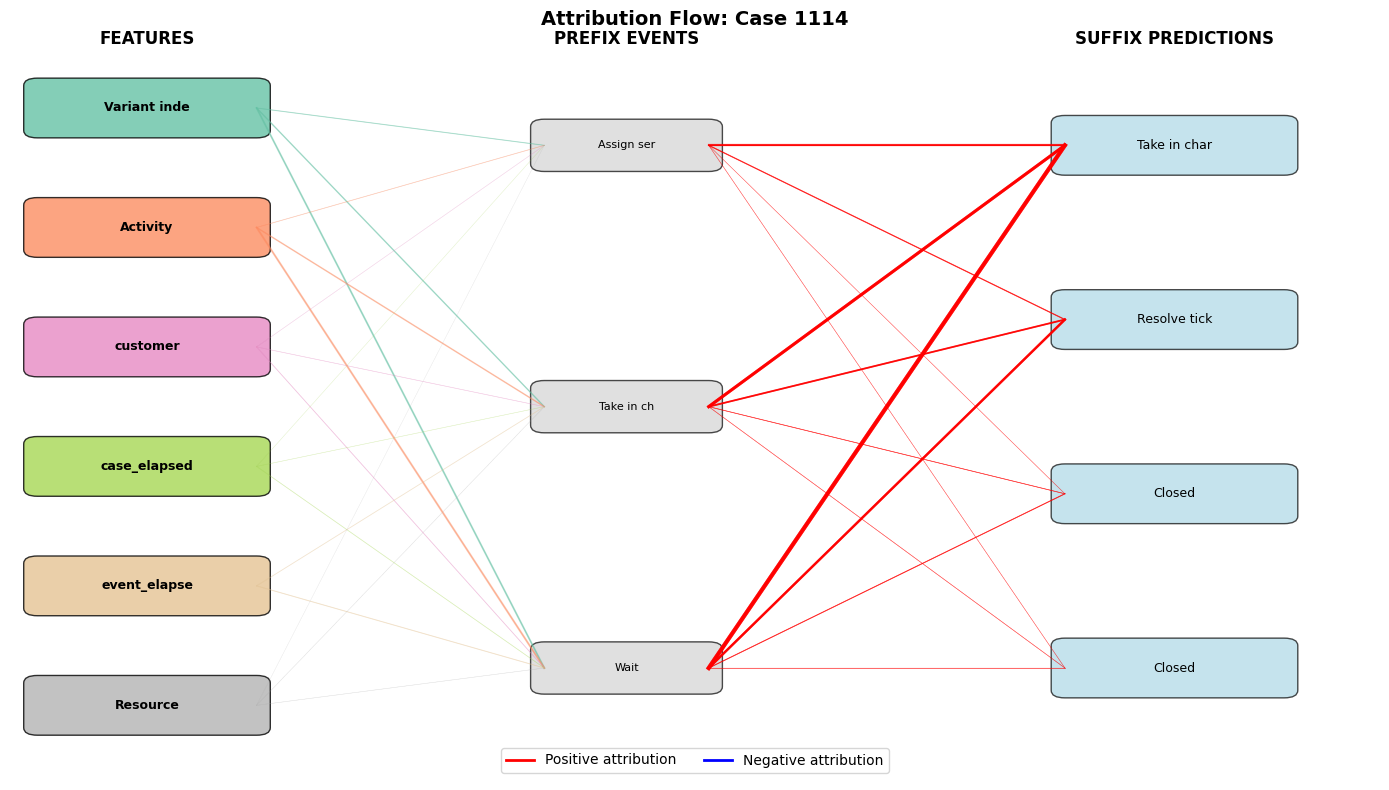

In [6]:
def plot_sankey_style(cube, feature_names, step_labels, suffix_labels, top_k=6):
    """Sankey-style visualization showing feature-to-prediction flow."""
    n_features, n_prefix, n_suffix = cube.shape
    
    # Get top features by total attribution
    feature_totals = np.abs(cube).sum(axis=(1, 2))
    top_feat_idx = np.argsort(feature_totals)[-top_k:][::-1]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Positions
    x_feat = 0.1
    x_prefix = 0.45
    x_suffix = 0.85
    
    # Colors for features
    colors = plt.cm.Set2(np.linspace(0, 1, top_k))
    
    # Draw feature boxes (left)
    feat_y = np.linspace(0.9, 0.1, top_k)
    for i, (f_idx, y) in enumerate(zip(top_feat_idx, feat_y)):
        box = FancyBboxPatch((x_feat - 0.08, y - 0.03), 0.16, 0.06,
                            boxstyle="round,pad=0.01", facecolor=colors[i], alpha=0.8)
        ax.add_patch(box)
        ax.text(x_feat, y, feature_names[f_idx][:12], ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Draw prefix boxes (middle)
    prefix_y = np.linspace(0.85, 0.15, n_prefix)
    for j, y in enumerate(prefix_y):
        box = FancyBboxPatch((x_prefix - 0.06, y - 0.025), 0.12, 0.05,
                            boxstyle="round,pad=0.01", facecolor='lightgray', alpha=0.7)
        ax.add_patch(box)
        label = step_labels[j][:10] if len(step_labels[j]) > 10 else step_labels[j]
        ax.text(x_prefix, y, label, ha='center', va='center', fontsize=8)
    
    # Draw suffix boxes (right)
    suffix_y = np.linspace(0.85, 0.15, n_suffix)
    for s, y in enumerate(suffix_y):
        box = FancyBboxPatch((x_suffix - 0.08, y - 0.03), 0.16, 0.06,
                            boxstyle="round,pad=0.01", facecolor='lightblue', alpha=0.7)
        ax.add_patch(box)
        label = suffix_labels[s][:12] if len(suffix_labels[s]) > 12 else suffix_labels[s]
        ax.text(x_suffix, y, label, ha='center', va='center', fontsize=9)
    
    # Draw flows (feature -> prefix -> suffix)
    max_attr = np.abs(cube[top_feat_idx]).max()
    
    for i, f_idx in enumerate(top_feat_idx):
        for j in range(n_prefix):
            for s in range(n_suffix):
                attr = cube[f_idx, j, s]
                if abs(attr) > 0.01:  # Only draw significant flows
                    width = abs(attr) / max_attr * 3
                    alpha = min(0.8, abs(attr) / max_attr + 0.2)
                    color = 'red' if attr > 0 else 'blue'
                    
                    # Feature to prefix
                    ax.plot([x_feat + 0.08, x_prefix - 0.06], [feat_y[i], prefix_y[j]],
                           color=colors[i], alpha=alpha * 0.5, linewidth=width * 0.5)
                    # Prefix to suffix
                    ax.plot([x_prefix + 0.06, x_suffix - 0.08], [prefix_y[j], suffix_y[s]],
                           color=color, alpha=alpha, linewidth=width)
    
    # Labels
    ax.text(x_feat, 0.98, 'FEATURES', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(x_prefix, 0.98, 'PREFIX EVENTS', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(x_suffix, 0.98, 'SUFFIX PREDICTIONS', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Legend
    ax.plot([], [], color='red', linewidth=2, label='Positive attribution')
    ax.plot([], [], color='blue', linewidth=2, label='Negative attribution')
    ax.legend(loc='lower center', ncol=2)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(f'Attribution Flow: {CASE_NAME}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = plot_sankey_style(cube, feature_names, step_labels, suffix_labels)
plt.show()